# Figure 4 — Analysis of the data-driven model (healthy vs BRCA+CRC)

**Panels** — (a) best (solid) and mean (dashed) AUROC across nested-CV
configurations as a function of the number of selected TSSs (k), stratified
by fragmentomic feature; (b) the same stratified by classifier; (c) ROC of
the locus-level data-driven model against five aggregate baselines in which
each fragmentomic feature is computed on a single composite coverage profile
pooled across all TSSs.

**Source data** (nothing else is read — no pickles, no cluster paths, no
network):
- `data/fig4_auc_sweep.csv` — outer-fold test AUROC for every nested-CV
  configuration (feature × classifier × ranking function × k × fold).
- `data/fig4c_aggregate_scores.csv` — per task sample: outer fold, label,
  the five pooled aggregate feature values, and the best data-driven model's
  out-of-fold score. `n_rows_in_source` records the row multiplicity of the
  original aggregate table (16 duplicated healthy samples), which the
  original analysis used as-is.

Both written by `export/export_fig4.py`. The submitted figure was assembled
from two notebooks plus a manual paste-in of panel c; this notebook draws
all three panels directly. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc

CLASSIFIER_COLORS = {
    "KNN": "#0173B2", "Logistic Regression": "#DE8F05",
    "Multi-Layer Perceptron": "#029E73", "Random Forest": "#CC78BC",
    "Support Vector Machine": "#CA3542",
}
FEATURE_COLORS = {
    "fslr": (46/255, 37/255, 133/255), "fslr_coverage": (51/255, 117/255, 56/255),
    "griffin_diff": (93/255, 168/255, 153/255), "rcov": (220/255, 205/255, 125/255),
    "mwh": (159/255, 74/255, 150/255),
}
FEATURE_NAME_MAP = {"fslr": "FSLR", "fslr_coverage": "FSLRC", "griffin_diff": "GD",
                    "rcov": "RCOV", "mwh": "MWH"}
CLASSIFIER_NAME_MAP = {"KNN": "KNN", "Logistic Regression": "LR",
                       "Multi-Layer Perceptron": "MLP", "Random Forest": "RF",
                       "Support Vector Machine": "SVM"}
AGG_DISPLAY = {"aggregate_griffin_diff": "GD (agg)", "aggregate_rcov": "RCOV (agg)",
               "aggregate_mwh": "MWH (agg)", "aggregate_fslr": "FSLR (agg)",
               "aggregate_fslr_coverage": "FSLRC (agg)"}
AGG_COLORS = {"aggregate_griffin_diff": FEATURE_COLORS["griffin_diff"],
              "aggregate_rcov": FEATURE_COLORS["rcov"],
              "aggregate_mwh": FEATURE_COLORS["mwh"],
              "aggregate_fslr": FEATURE_COLORS["fslr"],
              "aggregate_fslr_coverage": FEATURE_COLORS["fslr_coverage"]}
DD_COLOR = "#0173B2"

In [2]:
sweep = pd.read_csv("data/fig4_auc_sweep.csv")
fig4c = pd.read_csv("data/fig4c_aggregate_scores.csv")

summary = (sweep.groupby(["feature", "classifier", "weighting_function", "top_genes"])
           ["auc"].agg(mean_full_auc="mean", std_full_auc=lambda s: s.std(ddof=1))
           .reset_index().rename(columns={"top_genes": "n_genes"}))
best_auc = float(summary["mean_full_auc"].max())
print(f"{len(summary)} configurations; best mean AUROC = {best_auc:.3f}")

1485 configurations; best mean AUROC = 0.951


## Panels a and b — AUROC vs number of TSSs

Per group we plot two traces per k: solid = the best mean AUROC across the
remaining configuration dimensions at that k, dashed = the mean across them.

In [3]:
def _best_and_mean_per_k(sub):
    agg = sub.groupby("n_genes").agg(mean=("mean_full_auc", "mean"),
                                     best=("mean_full_auc", "max"))
    return agg.index.to_numpy(), agg["best"].to_numpy(), agg["mean"].to_numpy()


def _style_axis(ax):
    ax.set_xscale("log")
    ax.set_ylim(0.55, 1.0)
    ax.tick_params(labelsize=9)
    ax.grid(True, which="major", linestyle=":", linewidth=0.6,
            color="0.7", alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color("black")


def _add_best_reference(ax, best_auc):
    ax.axhline(best_auc, color="black", linestyle="--", linewidth=1.0, alpha=0.8, zorder=1)
    ax.text(ax.get_xlim()[0], best_auc, f" Best AUROC = {best_auc:.3f} ",
            ha="left", va="bottom", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor="none", alpha=0.85), zorder=4)


def panel_sweep(ax, group_col, colors, name_map, legend_title):
    from matplotlib.lines import Line2D
    order = (summary.groupby(group_col)["mean_full_auc"].max()
             .sort_values(ascending=False).index.tolist())
    for key in order:
        sub = summary[summary[group_col] == key]
        k, best, mean = _best_and_mean_per_k(sub)
        color = colors.get(key, "#999999")
        ax.plot(k, best, marker="o", markersize=5, linewidth=2.4, color=color,
                zorder=3, label=name_map.get(key, key))
        ax.plot(k, mean, linestyle="--", linewidth=1.2, color=color, alpha=0.45, zorder=2)
    _style_axis(ax)
    _add_best_reference(ax, best_auc)
    ax.set_xlabel("Number of Genes", fontsize=15)
    ax.set_ylabel("AUROC", fontsize=15)
    style_handles = [Line2D([0], [0], color="0.3", linewidth=2.4, linestyle="-"),
                     Line2D([0], [0], color="0.3", linewidth=1.2, linestyle="--", alpha=0.6)]
    h, l = ax.get_legend_handles_labels()
    ax.legend(h + style_handles, l + ["Best AUROC", "Mean AUROC"],
              loc="lower right", fontsize=8, frameon=True, framealpha=0.92,
              title=legend_title, title_fontsize=8)

## Panel c — locus-level model vs pooled aggregates

The aggregate baselines are one pooled value per sample, so their per-fold
ROC is computed on each outer fold's test samples (rows repeated by
`n_rows_in_source`, matching the original computation).

In [4]:
def panel_aggregates(ax):
    base_fpr = np.linspace(0, 1, 101)

    def mean_roc(score_col, expand_rows=True):
        # The aggregate values inherit the duplicate rows of the original
        # aggregate table (expand); the data-driven scores come from the
        # nested-CV pickles where each sample appears exactly once (no expand).
        tprs, aucs = [], []
        for _, g in fig4c.groupby("fold"):
            if expand_rows:
                g = g.loc[g.index.repeat(g["n_rows_in_source"])]
            g = g.dropna(subset=[score_col])
            fpr, tpr, _ = roc_curve(g["y_true"], g[score_col])
            tprs.append(interp1d(fpr, tpr, kind="linear")(base_fpr))
            aucs.append(auc(fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[0], mean_tpr[-1] = 0, 1
        return mean_tpr, np.std(tprs, axis=0), np.mean(aucs), np.std(aucs)

    mean_tpr, std_tpr, m_auc, s_auc = mean_roc("dd_score", expand_rows=False)
    ax.plot(base_fpr, mean_tpr, label=f"Data-driven - AUC = {m_auc:.3f} ± {s_auc:.3f}",
            color=DD_COLOR, linewidth=3, linestyle="-")
    ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0),
                    np.minimum(mean_tpr + std_tpr, 1), color=DD_COLOR, alpha=0.2)

    for feat, label in AGG_DISPLAY.items():
        mean_tpr, std_tpr, m_auc, s_auc = mean_roc(feat)
        ax.plot(base_fpr, mean_tpr, label=f"{label} - AUC = {m_auc:.3f} ± {s_auc:.3f}",
                color=AGG_COLORS[feat], linewidth=2, linestyle="--", alpha=0.8)
        ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0),
                        np.minimum(mean_tpr + std_tpr, 1), color=AGG_COLORS[feat], alpha=0.15)

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.2)
    ax.axvline(x=0.05, color="dimgray", linestyle=":", linewidth=1.6, alpha=0.85,
               zorder=1, label="95% specificity (FPR = 0.05)")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=10, frameon=True, framealpha=0.9,
              edgecolor="#cccccc", ncol=1)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color("black")

## Assemble Figure 4

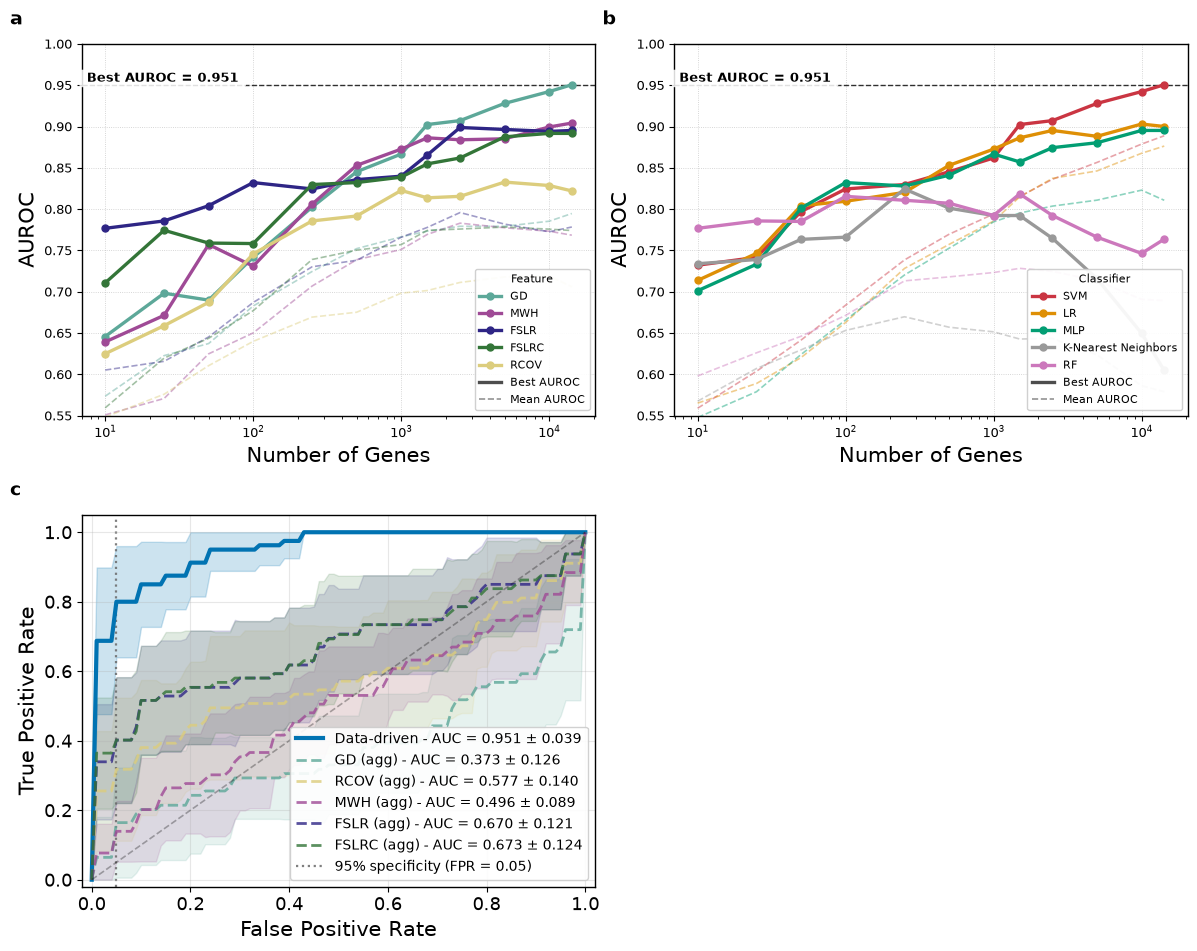

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9.6))
(axA, axB), (axC, axD) = axes
panel_sweep(axA, "feature", FEATURE_COLORS, FEATURE_NAME_MAP, "Feature")
panel_sweep(axB, "classifier", CLASSIFIER_COLORS, CLASSIFIER_NAME_MAP, "Classifier")
panel_aggregates(axC)
axD.axis("off")
for ax, letter in zip((axA, axB, axC), "abc"):
    ax.text(-0.14, 1.04, letter, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="bottom", ha="left")
plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/fig4.png", dpi=300, bbox_inches="tight")
fig.savefig("output/fig4.pdf", bbox_inches="tight")
plt.show()

## Check against the submitted manuscript values

In [6]:
print(f"Best AUROC annotation: {best_auc:.3f}   (manuscript: 0.951)")
gd = summary[(summary["feature"] == "griffin_diff") & (summary["n_genes"] == 14224)]
print(f"griffin_diff best mean AUROC at k=14224: {gd['mean_full_auc'].max():.3f}")

dd_aucs = []
for _, g in fig4c.groupby("fold"):
    fpr, tpr, _ = roc_curve(g["y_true"], g["dd_score"])
    dd_aucs.append(auc(fpr, tpr))
print(f"Panel c Data-driven: {np.mean(dd_aucs):.3f} ± {np.std(dd_aucs):.3f}   "
      f"(manuscript: 0.951 ± 0.039)")

ref = {"aggregate_griffin_diff": (0.373, 0.126), "aggregate_rcov": (0.577, 0.140),
       "aggregate_mwh": (0.496, 0.089), "aggregate_fslr": (0.670, 0.121),
       "aggregate_fslr_coverage": (0.673, 0.124)}
print("\nPanel c aggregate AUCs (computed vs manuscript legend):")
for feat, (m_ref, s_ref) in ref.items():
    aucs = []
    for _, g in fig4c.groupby("fold"):
        g = g.loc[g.index.repeat(g["n_rows_in_source"])].dropna(subset=[feat])
        fpr, tpr, _ = roc_curve(g["y_true"], g[feat])
        aucs.append(auc(fpr, tpr))
    print(f"  {AGG_DISPLAY[feat]:<12} {np.mean(aucs):.3f} ± {np.std(aucs):.3f}   "
          f"(manuscript: {m_ref:.3f} ± {s_ref:.3f})")

Best AUROC annotation: 0.951   (manuscript: 0.951)
griffin_diff best mean AUROC at k=14224: 0.951
Panel c Data-driven: 0.951 ± 0.039   (manuscript: 0.951 ± 0.039)

Panel c aggregate AUCs (computed vs manuscript legend):
  GD (agg)     0.373 ± 0.126   (manuscript: 0.373 ± 0.126)
  RCOV (agg)   0.577 ± 0.140   (manuscript: 0.577 ± 0.140)
  MWH (agg)    0.496 ± 0.089   (manuscript: 0.496 ± 0.089)
  FSLR (agg)   0.670 ± 0.121   (manuscript: 0.670 ± 0.121)
  FSLRC (agg)  0.673 ± 0.124   (manuscript: 0.673 ± 0.124)
